## 1. Import libraries and data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().resolve().parents[0]
sys.path.append(str(PROJECT_DIR))

from src.clustering import k_distance_elbow_plot

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [3]:
PROJECT_DIR = Path.cwd().resolve().parents[0]

data_path = PROJECT_DIR / "data" / "processed" / "model_table.csv"

df = pd.read_csv(data_path)

FEATURE_COLS = ["Age", "Annual_income_thousands", "Spending_score"]
CATEGORY_COL = ["Gender"]
X = df[FEATURE_COLS]
X.head()

,Age,Annual_income_thousands,Spending_score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


## 2. Standardize data

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Find K with inertia + silhouette + DB + CH

In [5]:
k_values = range(2,11)
rows = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    labels = km.fit_predict(X_scaled)

    inertia = km.inertia_
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)

    rows.append({"k": k, "inertia": inertia, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


metrics =  pd.DataFrame(rows)
metrics

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,389.386189,0.335472,1.260682,107.095567
1,3,295.456245,0.357923,1.032689,101.529619
2,4,205.225147,0.403958,0.930796,125.676397
3,5,169.891498,0.408469,0.888969,123.418710
4,6,134.352775,0.431065,0.834966,134.475171
5,7,121.389350,0.410091,0.880755,126.825864
6,8,113.727230,0.367366,0.952068,117.278574
7,9,102.136238,0.374421,0.918146,116.378843
8,10,92.550272,0.361870,0.988547,115.751443


## 4. K plots

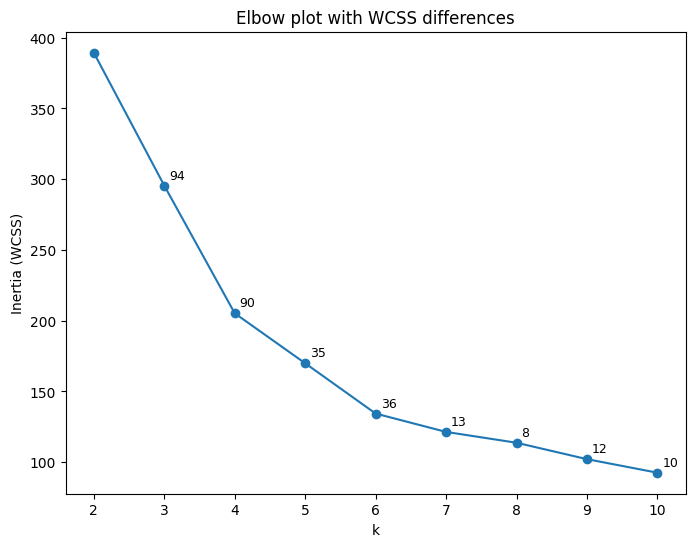

In [6]:
# Elbow plot

SAVE_FIG = PROJECT_DIR / "reports" / "figures" / "elbow.png"

diffs = []
diffs = [metrics["inertia"][i-1] - metrics["inertia"][i] for i in range(1, len(metrics["inertia"]))]

plt.figure(figsize=(8,6))
plt.plot(metrics["k"], metrics["inertia"], marker = "o")

for i, d in enumerate(diffs, start=2):
    plt.text(
        i + 1.07, metrics["inertia"][i-1] + (0.03 * metrics["inertia"][0]), 
        f"{d:.0f}",
        ha="left", va="top", fontsize=9, color="black"
    )

plt.xlabel("k")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow plot with WCSS differences")
plt.xticks(list(k_values))

plt.savefig(SAVE_FIG, dpi = 300, bbox_inches = "tight")
plt.show()
plt.close()

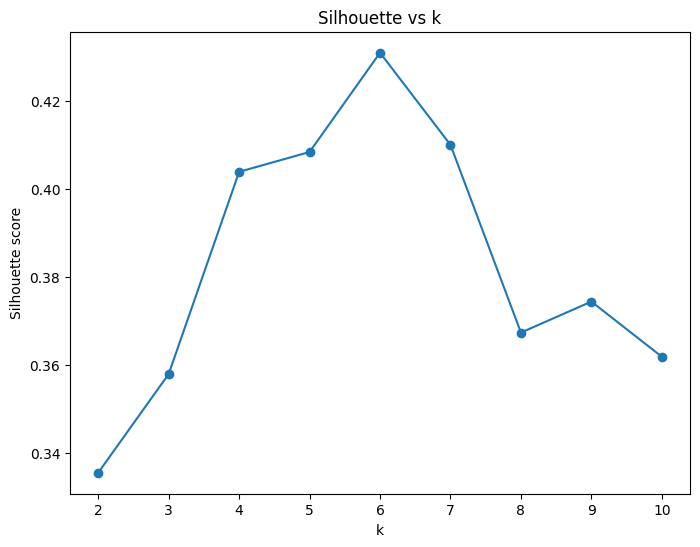

In [7]:
# Silhouette plot

SAVE_FIG = PROJECT_DIR / "reports" / "figures" / "silhouette.png"

plt.figure(figsize=(8,6))
plt.plot(metrics["k"], metrics["silhouette"], marker = "o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k")
plt.xticks(list(k_values))

plt.savefig(SAVE_FIG, dpi = 300, bbox_inches = "tight")
plt.show()
plt.close()

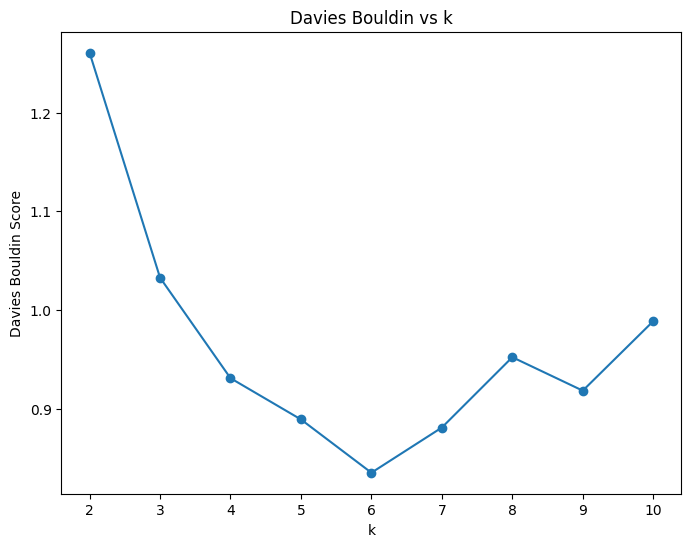

In [8]:
# Davies Bouldin plot

SAVE_FIG = PROJECT_DIR / "reports" / "figures" / "db.png"

plt.figure(figsize=(8,6))
plt.plot(metrics["k"], metrics["davies_bouldin"], marker = "o")
plt.xlabel("k")
plt.ylabel("Davies Bouldin Score")
plt.title("Davies Bouldin vs k")
plt.xticks(list(k_values))

plt.savefig(SAVE_FIG, dpi = 300, bbox_inches = "tight")
plt.show()
plt.close()

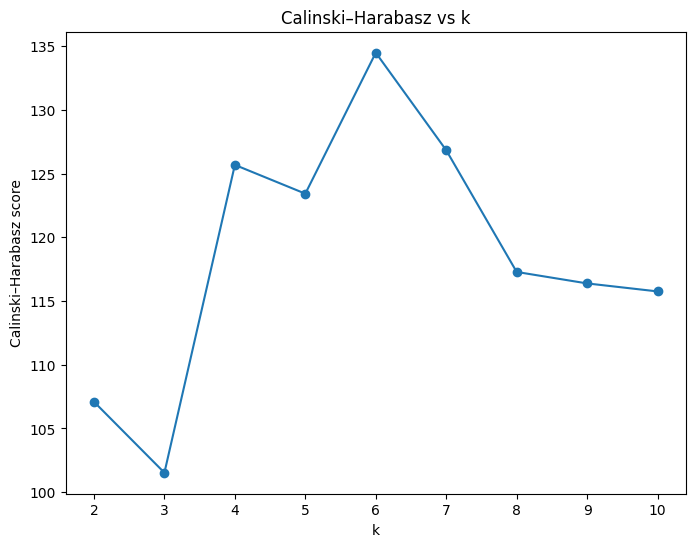

In [9]:
# Calinski–Harabasz plot

SAVE_FIG = PROJECT_DIR / "reports" / "figures" / "ch.png"

plt.figure(figsize=(8,6))
plt.plot(metrics["k"], metrics["calinski_harabasz"], marker = "o")
plt.xlabel("k")
plt.ylabel("Calinski–Harabasz score")
plt.title("Calinski–Harabasz vs k")
plt.xticks(list(k_values))

plt.savefig(SAVE_FIG, dpi = 300, bbox_inches = "tight")
plt.show()
plt.close()

## 5. KMeans

In [10]:
BEST_K = 6

In [11]:
kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=42,
    n_init="auto"
    )

clusters = kmeans.fit_predict(X_scaled)

df_model = X.copy()
df_model["cluster"] = clusters
df["cluster"] = clusters
df_model["cluster"].value_counts().sort_index()

cluster
0    45
1    39
2    25
3    40
4    30
5    21
Name: count, dtype: int64

## 5.1 Centroids

In [ ]:
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(centers, columns=FEATURE_COLS)
centers_df.insert(0, "cluster", range(BEST_K))
print(centers_df)

df_original = df[FEATURE_COLS].to_numpy()

   cluster        Age  Annual_income_thousands  Spending_score
0        0  56.333333                54.266667       49.066667
1        1  32.692308                86.538462       82.128205
2        2  25.560000                26.480000       76.240000
3        3  26.125000                59.425000       44.450000
4        4  44.000000                90.133333       17.933333
5        5  45.523810                26.285714       19.380952


## 5.2 Cluster summary

In [13]:
summary = (
    df_model
    .groupby("cluster")[FEATURE_COLS]
    .agg(["count", "mean", "median", "std"])
)
summary

Age                              Annual_income_thousands             \
        count       mean median        std                   count       mean   
cluster                                                                         
0          45  56.333333   54.0   8.453079                      45  54.266667   
1          39  32.692308   32.0   3.728650                      39  86.538462   
2          25  25.560000   24.0   5.439669                      25  26.480000   
3          40  26.125000   25.0   7.031750                      40  59.425000   
4          30  44.000000   43.5   8.081482                      30  90.133333   
5          21  45.523810   46.0  11.766984                      21  26.285714   

                          Spending_score                               
        median        std          count       mean median        std  
cluster                                                                
0         54.0   8.975725             45  49.066667   49.0   6.300794  
1         79.0  16.312485             39  82.128205   83.0   9.364489  
2         25.0   8.525061             25  76.240000   76.0  13.562448  
3         60.0  10.587577             40  44.450000   48.0  14.279176  
4         87.0  16.919145             30  17.933333   16.5   9.888807  
5         25.0   7.437357             21  19.380952   15.0  12.555780

### Clusters found:
0 - Older customers, middle earners and middle spenders (Age ~56, Income ~54k, Score ~49)  
1 - Young professionals, high earners and high spenders (Age ~33, Income ~87k, Score ~82)  
2 - Young professionals, low earners and high spenders (Age ~26, Income ~26k, Score ~76)  
3 - Young professionals, middle earners and middle spenders  (Age ~26, Income ~59k, Score ~44)  
4 - Mid-career adults, high earners and low spenders  (Age ~44, Income ~90k, Score ~18)  
5 - Pre-retirment individuals, low earners and low spenders (Age ~46, Income ~26k, Score ~19)  

## 5.3 Plot clusters

In [23]:
import plotly.graph_objects as go
import plotly.express as px

# plot dataframe
plot_df = pd.DataFrame(df_original, columns=FEATURE_COLS).assign(
    cluster=clusters.astype(str)
)

# points
fig = px.scatter_3d(
    plot_df,
    x=FEATURE_COLS[0],
    y=FEATURE_COLS[1],
    z=FEATURE_COLS[2],
    color="cluster",
    opacity=0.85,
)

# centroids
fig.add_trace(go.Scatter3d(
    x=centers[:, 0],
    y=centers[:, 1],
    z=centers[:, 2],
    mode="markers",
    marker=dict(
        size=8,
        symbol="x",
        color="red",
        line=dict(width=2, color="black")
    ),
    name="Centroids"
))

fig.update_layout(
    title="KMeans clusters (3D) with centroids",
    scene=dict(
        xaxis_title=FEATURE_COLS[0],
        yaxis_title=FEATURE_COLS[1],
        zaxis_title=FEATURE_COLS[2],
    ),
    legend=dict(
        title="Cluster",
        itemsizing="constant",
        x=1.15,
        y=1,
        xanchor="left",
        yanchor="top"
    ),
    margin=dict(r=180)
)

fig.show()
fig.write_html(f"{PROJECT_DIR}/reports/figures/KMeans_clusters_3d.html", include_plotlyjs="cdn")